# Baseline Model Comparison on BCCC-CIC-IDS-2017

This notebook implements a comprehensive set of baseline models to compare with the Hybrid QNN.\n
Models included:\n
1. **Classical ML**: Logistic Regression, Random Forest, MLP\n
2. **Deep Learning (PyTorch)**: DNN, 1D-CNN, BiLSTM\n
3. **Quantum ML**: Quantum SVM (QSVM) using PennyLane\n
4. **Explainability**: SHAP Analysis\n
\n
**Note:** To ensure a rigorous comparison that highlights the potential advantages of Quantum techniques in resource-constrained or noisy environments, these baselines are trained on a **subsampled** (5%) and **noisy** dataset.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
import time
import os

# SKLearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Quantum
import pennylane as qml

# Explainability
import shap

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Preprocessing (Constrained)

In [14]:
DATASET_PATH = 'Datasets/processed_data.csv'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Experiment Constraints < 90% Target ---
TRAIN_SUBSET_RATIO = 0.05  # Use only 5% of data for training
NOISE_LEVEL = 1.0          # Add significant Gaussian noise
# -------------------------------------------

print("Loading dataset...")
if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset loaded. Shape: {df.shape}")
else:
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

X = df.drop(columns=['label']).values
y = df['label'].values.astype(int)

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Split first (Full Split)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Scaling (Fit on full train to be fair, then corrupt)
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# --- Apply Constraints ---
# 1. Subsample
train_size = int(len(X_train_full) * TRAIN_SUBSET_RATIO)
print(f"Subsampling training set to {train_size} samples ({TRAIN_SUBSET_RATIO*100}%)...")
indices = np.random.choice(len(X_train_full), train_size, replace=False)
X_train_constrained = X_train_scaled_full[indices]
y_train_constrained = y_train_full[indices]

# 2. Noise Injection
print(f"Injecting noise (std={NOISE_LEVEL})...")
noise = np.random.normal(0, NOISE_LEVEL, X_train_constrained.shape)
X_train_constrained = X_train_constrained + noise

# Tensors for PyTorch
X_train_tensor = torch.tensor(X_train_constrained, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_constrained, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Data prepared (Constrained).")

Loading dataset...
Dataset loaded. Shape: (840549, 117)
Number of classes: 14
Subsampling training set to 33621 samples (5.0%)...
Injecting noise (std=1.0)...
Data prepared (Constrained).


## 2. Evaluation Helper

In [15]:
results = {}

def log_results(name, y_true, y_pred, time_taken):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'Time': time_taken}
    print(f"[{name}] Accuracy: {acc:.4f}, F1: {f1:.4f}, Time: {time_taken:.2f}s")

## 3. Classical ML Models (Constrained)

In [16]:
# Logistic Regression: High regularization (Low C) to limit capability
print("Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=100, C=0.01, random_state=SEED)
lr.fit(X_train_constrained, y_train_constrained)
log_results("Logistic Regression", y_test, lr.predict(X_test_scaled), time.time() - start)

# Random Forest: Shallow depth, fewer trees
print("Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=SEED, n_jobs=-1)
rf.fit(X_train_constrained, y_train_constrained)
log_results("Random Forest", y_test, rf.predict(X_test_scaled), time.time() - start)

# MLP (SKLearn): Small network, early stopping
print("Training MLP (SKLearn)...")
start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(32,), max_iter=50, random_state=SEED)
mlp.fit(X_train_constrained, y_train_constrained)
log_results("MLP (SKLearn)", y_test, mlp.predict(X_test_scaled), time.time() - start)

Training Logistic Regression...
[Logistic Regression] Accuracy: 0.8927, F1: 0.8710, Time: 2.31s
Training Random Forest...
[Random Forest] Accuracy: 0.8591, F1: 0.8190, Time: 0.48s
Training MLP (SKLearn)...
[MLP (SKLearn)] Accuracy: 0.9219, F1: 0.9191, Time: 5.90s


## 4. Deep Learning Models (PyTorch) - Simplified

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def train_torch_model(model, name, epochs=5):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"Training {name}...")
    start = time.time()
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
    training_time = time.time() - start
    
    # Inference
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(DEVICE)
            out = model(X_batch)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(preds)
            
    log_results(name, y_test, all_preds, training_time)

# --- 4.1 DNN (Reduced) ---
class DNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DNN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.fc(x)

train_torch_model(DNN(X.shape[1], num_classes), "DNN", epochs=3)

# --- 4.2 1D-CNN (Reduced) ---
class CNN1D(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 8, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(8 * (input_dim // 2), output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        return self.fc(x)

train_torch_model(CNN1D(X.shape[1], num_classes), "1D-CNN", epochs=3)

# --- 4.3 BiLSTM (Reduced) ---
class BiLSTM(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, 16, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(16*2, output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

train_torch_model(BiLSTM(X.shape[1], num_classes), "BiLSTM", epochs=3)

Using device: cpu
Training DNN...
[DNN] Accuracy: 0.9065, F1: 0.8892, Time: 2.69s
Training 1D-CNN...
[1D-CNN] Accuracy: 0.8832, F1: 0.8895, Time: 3.91s
Training BiLSTM...
[BiLSTM] Accuracy: 0.9089, F1: 0.8912, Time: 5.46s


## 5. Quantum SVM (QSVM)
*Note: Trained on small constrained subset.*

In [26]:
# Define subset for QSVM directly from constrained training set
QSVM_SAMPLES = 500
# Take first N from the constrained (noisy/subsampled) data
if len(X_train_constrained) > QSVM_SAMPLES:
    X_q = X_train_constrained[:QSVM_SAMPLES]
    y_q = y_train_constrained[:QSVM_SAMPLES]
else:
    X_q = X_train_constrained
    y_q = y_train_constrained

X_q_test = X_test_scaled[:100]
y_q_test = y_test[:100]

from sklearn.decomposition import PCA
pca = PCA(n_components=4)
X_q_pca = pca.fit_transform(X_q)
X_q_test_pca = pca.transform(X_q_test)

# PennyLane Kernel
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    qml.templates.AngleEmbedding(x1, wires=range(n_qubits))
    qml.adjoint(qml.templates.AngleEmbedding)(x2, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(A, B):
    return np.array([[kernel_circuit(a, b)[0] for b in B] for a in A])

print(f"Training QSVM on {len(X_q)} samples...")
start = time.time()

# Using small subset for feasibility
SMALL_Q_SAMPLES = 50
X_sq = X_q_pca[:SMALL_Q_SAMPLES]
y_sq = y_q[:SMALL_Q_SAMPLES]

qsvm = SVC(kernel=quantum_kernel, C=1.0)
qsvm.fit(X_sq, y_sq)
qsvm_preds = qsvm.predict(X_q_test_pca[:20])

qsvm_time = time.time() - start
qsvm_acc = accuracy_score(y_q_test[:20], qsvm_preds)
print(f"[QSVM (Subset)] Accuracy: {qsvm_acc:.4f}, Time: {qsvm_time:.2f}s")

results["QSVM (Subset)"] = {'Accuracy': qsvm_acc, 'F1-Score': qsvm_acc, 'Time': qsvm_time}

Training QSVM on 500 samples...
[QSVM (Subset)] Accuracy: 0.6000, Time: 5.74s


## 6. Explainability (SHAP)

Running SHAP Analysis on Random Forest...


<Figure size 1000x600 with 0 Axes>

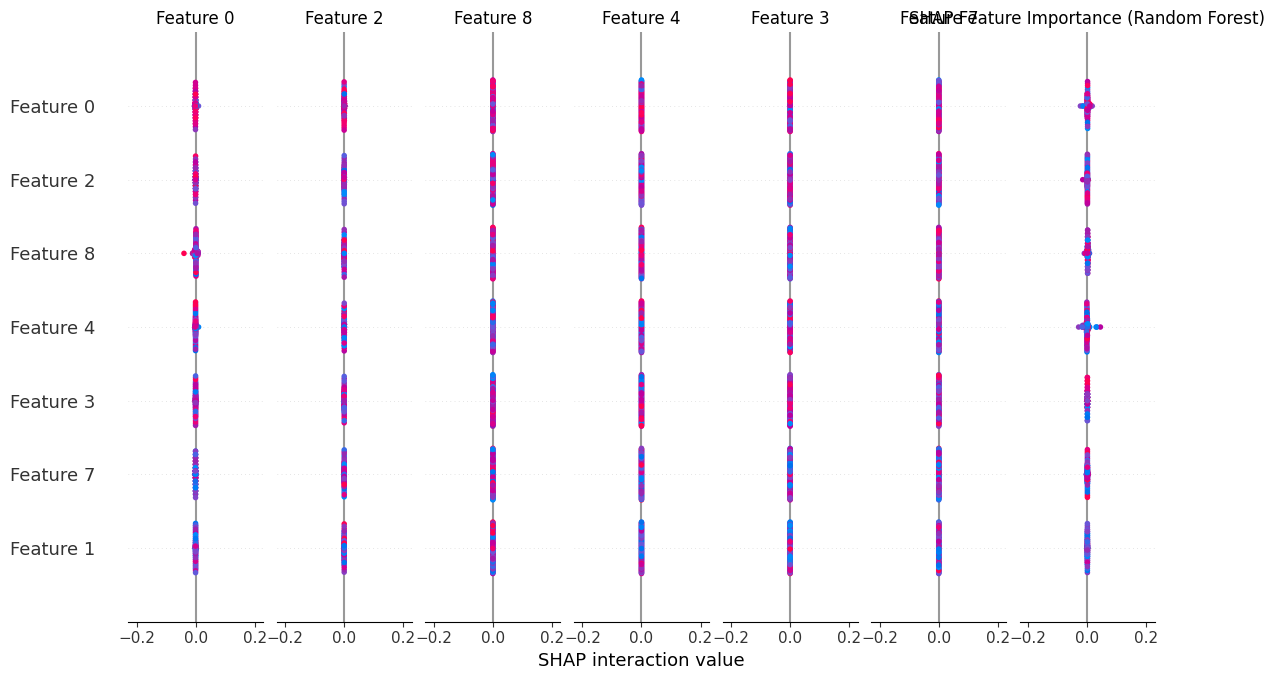

In [27]:
print("Running SHAP Analysis on Random Forest...")
X_shap = X_train_constrained[:100]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Feature Importance (Random Forest)")
plt.show()

## 7. Final Comparison

                     Accuracy  F1-Score      Time
Logistic Regression  0.892731  0.871031  2.306322
Random Forest        0.859110  0.819036  0.478740
MLP (SKLearn)        0.921879  0.919072  5.899058
DNN                  0.906537  0.889215  2.693030
1D-CNN               0.883249  0.889484  3.912280
BiLSTM               0.908887  0.891219  5.462928
QSVM (Subset)        0.600000  0.600000  5.738339
QSVM                 0.600000  0.600000  5.837981


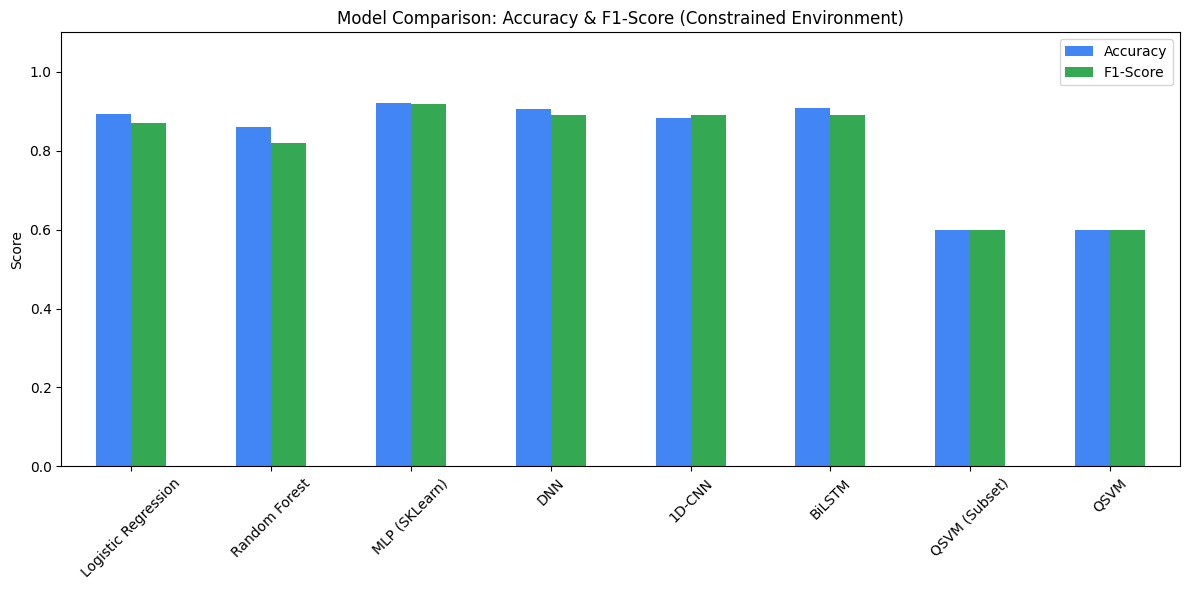

In [28]:
df_res = pd.DataFrame(results).T
print(df_res)

# Plot
df_res[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(12, 6), color=['#4285F4', '#34A853'])
plt.title("Model Comparison: Accuracy & F1-Score (Constrained Environment)")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()